### **This notebook generate the analisys to grid search results**

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import re

In [2]:
ROOT = Path("..")
INPUT_DIR = ROOT / "reports" / "topic_modeling" / "grid_search"

In [3]:
dfs = []
for model_dir in INPUT_DIR.iterdir():
    if not model_dir.is_dir():
        continue
    csv_path = model_dir / "grid_search_results.csv"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    df["embedding_model"] = model_dir.name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total de linhas carregadas: {len(df_all)} de {df_all['embedding_model'].nunique()} modelos")
df_all

Total de linhas carregadas: 864 de 3 modelos


,n_neighbors,n_components,min_dist,metric,min_cluster_size,min_samples,hdbscan_metric,cluster_selection_method,prediction_data,n_topics,silhouette,diversity,coherence_cv,silhouette_norm,diversity_norm,coherence_cv_norm,score_sdc,score_sc,embedding_model
0,15,3,0.0,cosine,10,5,euclidean,eom,True,1000,0.0544,0.7296,0.4480,0.400879,0.938918,0.000000,0.446599,0.200440,all-distilroberta-v1
1,15,3,0.0,cosine,10,10,euclidean,eom,True,708,0.0737,0.6829,0.5012,0.485714,0.808069,0.151394,0.481726,0.318554,all-distilroberta-v1
2,15,3,0.0,cosine,10,20,euclidean,eom,True,409,0.0723,0.6237,0.5604,0.479560,0.642197,0.319863,0.480540,0.399712,all-distilroberta-v1
3,15,3,0.0,cosine,20,5,euclidean,eom,True,534,0.0735,0.6395,0.5229,0.484835,0.686467,0.213147,0.461483,0.348991,all-distilroberta-v1
4,15,3,0.0,cosine,20,10,euclidean,eom,True,433,0.0782,0.6231,0.5584,0.505495,0.640516,0.314172,0.486727,0.409833,all-distilroberta-v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,100,10,0.0,cosine,150,10,euclidean,eom,True,48,-0.0269,0.4542,0.7843,0.193353,0.278051,0.940486,0.470630,0.566920,paraphrase-MiniLM-L6-v2
860,100,10,0.0,cosine,150,20,euclidean,eom,True,47,-0.0189,0.4660,0.7751,0.227881,0.307087,0.914781,0.483249,0.571331,paraphrase-MiniLM-L6-v2
861,100,10,0.0,cosine,200,5,euclidean,eom,True,39,-0.0089,0.5282,0.7783,0.271040,0.460138,0.923722,0.551633,0.597381,paraphrase-MiniLM-L6-v2
862,100,10,0.0,cosine,200,10,euclidean,eom,True,39,-0.0088,0.5308,0.7796,0.271472,0.466535,0.927354,0.555120,0.599413,paraphrase-MiniLM-L6-v2


In [4]:
import ast  # <-- Adicione este import no início

def parse_grid_log(log_path: Path) -> pd.DataFrame:
    with open(log_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
 
    rows = []
    current_model = None
    pending = None
 
    combo_re = re.compile(r"^\[(\d+)/(\d+)\]\s+(\{.*\})\s*$")
    model_re = re.compile(r"^\[(\d+)/(\d+)\]\s+Modelo de embedding:\s+(.*)$")
    outliers_re = re.compile(r"Outliers \(ruído\):\s*(\d+)\s*\(([\d.]+)%\)")
    silhouette_re = re.compile(r"Silhoueta:\s*([-\d.]+|nan)")
    diversity_re = re.compile(r"Diversidade:\s*([-\d.]+|nan)")
    coherence_re = re.compile(r"Coerência \(c_v\):\s*([-\d.]+|nan)")
    falhou_re = re.compile(r"Falhou:\s*(.*)$")
 
    for line in lines:
        stripped = line.strip()
 
        m_model = model_re.match(stripped)
        if m_model:
            current_model = m_model.group(3).strip()
            continue
 
        m_combo = combo_re.match(stripped)
        if m_combo:
            if pending is not None:
                rows.append(pending)
            idx = int(m_combo.group(1))
            params_str = m_combo.group(3)
            try:
                # O ast.literal_eval traduz a string para um dicionário real Python
                params = ast.literal_eval(params_str)
            except Exception:
                params = {}
            
            # Aqui você já guarda "embedding_model" e desempacota todos os parâmetros individuais
            pending = {"embedding_model": current_model, "combo_idx": idx, **params}
            continue
 
        if pending is not None:
            m_out = outliers_re.search(line)
            if m_out:
                pending["n_outliers"] = int(m_out.group(1))
                pending["outliers_pct"] = float(m_out.group(2))
                continue
            m_sil = silhouette_re.search(line)
            if m_sil:
                val = m_sil.group(1)
                pending["silhouette"] = float(val) if val != "nan" else float("nan")
                continue
            m_div = diversity_re.search(line)
            if m_div:
                val = m_div.group(1)
                pending["diversity"] = float(val) if val != "nan" else float("nan")
                continue
            m_coh = coherence_re.search(line)
            if m_coh:
                val = m_coh.group(1)
                pending["coherence_cv"] = float(val) if val != "nan" else float("nan")
                continue
            m_fail = falhou_re.search(line)
            if m_fail:
                pending["error"] = m_fail.group(1).strip()
                continue
 
    if pending is not None:
        rows.append(pending)
 
    df = pd.DataFrame(rows)
 
    if "outliers_pct" in df.columns:
        incompletas = df["outliers_pct"].isna() & (
            df["error"].isna() if "error" in df.columns else True
        )
        if incompletas.any():
            print(f"Aviso: {incompletas.sum()} combinação(ões) incompleta(s) — removidas.")
            df = df[~incompletas].reset_index(drop=True)
 
    return df

In [5]:
LOG_PATH_1 = Path("..") / "grid_log.txt"
LOG_PATH_2 = Path("..") / "grid_log2.txt"

df_log_1 = parse_grid_log(LOG_PATH_1)
df_log_2 = parse_grid_log(LOG_PATH_2)

df_log = pd.concat([df_log_1, df_log_2], ignore_index=True)

print(df_log["embedding_model"].value_counts())

Aviso: 1 combinação(ões) incompleta(s) — removidas.
embedding_model
paraphrase-MiniLM-L6-v2    288
all-MiniLM-L6-v2           288
all-distilroberta-v1       288
Name: count, dtype: int64


In [6]:
df_log

,embedding_model,combo_idx,n_neighbors,n_components,min_dist,metric,min_cluster_size,min_samples,hdbscan_metric,cluster_selection_method,prediction_data,n_outliers,outliers_pct,silhouette,diversity,coherence_cv
0,paraphrase-MiniLM-L6-v2,1,15,3,0.0,cosine,10,5,euclidean,eom,True,40048.0,44.7,0.0575,0.7359,0.4488
1,paraphrase-MiniLM-L6-v2,2,15,3,0.0,cosine,10,10,euclidean,eom,True,39308.0,43.9,0.0594,0.6965,0.4896
2,paraphrase-MiniLM-L6-v2,3,15,3,0.0,cosine,10,20,euclidean,eom,True,41395.0,46.2,0.0634,0.6598,0.5424
3,paraphrase-MiniLM-L6-v2,4,15,3,0.0,cosine,20,5,euclidean,eom,True,39387.0,43.9,0.0655,0.6508,0.5166
4,paraphrase-MiniLM-L6-v2,5,15,3,0.0,cosine,20,10,euclidean,eom,True,39546.0,44.1,0.0681,0.6300,0.5457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,all-distilroberta-v1,284,100,10,0.0,cosine,150,10,euclidean,eom,True,39383.0,43.9,0.1739,0.6687,0.7253
860,all-distilroberta-v1,285,100,10,0.0,cosine,150,20,euclidean,eom,True,36841.0,41.1,0.1595,0.6672,0.7200
861,all-distilroberta-v1,286,100,10,0.0,cosine,200,5,euclidean,eom,True,38790.0,43.3,0.1907,0.6738,0.7203
862,all-distilroberta-v1,287,100,10,0.0,cosine,200,10,euclidean,eom,True,36749.0,41.0,0.1868,0.6655,0.7250


In [7]:
# 1. Defina quais colunas de hiperparâmetros serão usadas para bater os dados do CSV com o Log
param_cols = [
    "n_neighbors", "n_components", "min_dist", "metric",
    "min_cluster_size", "min_samples", "hdbscan_metric",
    "cluster_selection_method", "prediction_data"
]

# Filtra colunas que de fato existem nos dois lados
join_cols = ["embedding_model"] + [c for c in param_cols if c in df_all.columns and c in df_log.columns]

# 2. Conversão de tipos para garantir igualdade perfeita na hora de mesclar
for col in join_cols:
    if col in df_all.columns and col in df_log.columns:
        # Força o mesmo tipo nos dois DataFrames (removendo diferenças entre float/int/str)
        df_all[col] = df_all[col].astype(str).str.strip()
        df_log[col] = df_log[col].astype(str).str.strip()

# 3. Realiza o merge trazendo apenas as novas colunas que você quer recuperar do Log
df_all = df_all.merge(
    df_log[join_cols + ["outliers_pct", "n_outliers"]],
    on=join_cols,
    how="left"
)

print(f"Total de linhas final: {len(df_all)}")

Total de linhas final: 864


In [8]:
def add_normalized_scores(df: pd.DataFrame, suffix: str = "") -> pd.DataFrame:
    """Normaliza silhouette, diversity e coherence_cv (0-1) e calcula scores combinados."""
    df = df.copy()
    for col in ["silhouette", "diversity", "coherence_cv"]:
        min_v, max_v = df[col].min(), df[col].max()
        if max_v > min_v:
            df[f"{col}_norm{suffix}"] = (df[col] - min_v) / (max_v - min_v)
        else:
            df[f"{col}_norm{suffix}"] = 0.0

    df[f"score_sdc{suffix}"] = df[[f"silhouette_norm{suffix}", f"diversity_norm{suffix}", f"coherence_cv_norm{suffix}"]].mean(axis=1)
    df[f"score_sc{suffix}"] = df[[f"silhouette_norm{suffix}", f"coherence_cv_norm{suffix}"]].mean(axis=1)
    return df

In [9]:
df_all = add_normalized_scores(df_all, suffix="_global")

In [10]:
df_all

,n_neighbors,n_components,min_dist,metric,min_cluster_size,min_samples,hdbscan_metric,cluster_selection_method,prediction_data,n_topics,...,score_sdc,score_sc,embedding_model,outliers_pct,n_outliers,silhouette_norm_global,diversity_norm_global,coherence_cv_norm_global,score_sdc_global,score_sc_global
0,15,3,0.0,cosine,10,5,euclidean,eom,True,1000,...,0.446599,0.200440,all-distilroberta-v1,43.6,39072.0,0.480564,0.946855,0.007494,0.478304,0.244029
1,15,3,0.0,cosine,10,10,euclidean,eom,True,708,...,0.481726,0.318554,all-distilroberta-v1,46.0,41192.0,0.554116,0.833008,0.155148,0.514091,0.354632
2,15,3,0.0,cosine,10,20,euclidean,eom,True,409,...,0.480540,0.399712,all-distilroberta-v1,44.6,40007.0,0.548780,0.688688,0.319456,0.518975,0.434118
3,15,3,0.0,cosine,20,5,euclidean,eom,True,534,...,0.461483,0.348991,all-distilroberta-v1,43.3,38794.0,0.553354,0.727206,0.215376,0.498645,0.384365
4,15,3,0.0,cosine,20,10,euclidean,eom,True,433,...,0.486727,0.409833,all-distilroberta-v1,45.8,41012.0,0.571265,0.687226,0.313905,0.524132,0.442585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,100,10,0.0,cosine,150,10,euclidean,eom,True,48,...,0.470630,0.566920,paraphrase-MiniLM-L6-v2,6.1,5496.0,0.170732,0.275475,0.940883,0.462363,0.555807
860,100,10,0.0,cosine,150,20,euclidean,eom,True,47,...,0.483249,0.571331,paraphrase-MiniLM-L6-v2,4.8,4341.0,0.201220,0.304242,0.915348,0.473603,0.558284
861,100,10,0.0,cosine,200,5,euclidean,eom,True,39,...,0.551633,0.597381,paraphrase-MiniLM-L6-v2,4.4,3906.0,0.239329,0.455875,0.924230,0.539811,0.581780
862,100,10,0.0,cosine,200,10,euclidean,eom,True,39,...,0.555120,0.599413,paraphrase-MiniLM-L6-v2,4.6,4087.0,0.239710,0.462214,0.927838,0.543254,0.583774


### Resultados

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

#### Número de Tópicos

=== Number of Topics Global ===


count     864.00
mean      220.31
std       193.08
min        31.00
25%        78.00
50%       152.00
75%       305.25
max      1115.00
Name: n_topics, dtype: float64


=== Número de tópicos — por Embedding ===


,count,mean,std,min,25%,50%,75%,max
embedding_model,,,,,,,,
all-MiniLM-L6-v2,288.0,231.52,194.02,35.0,101.5,159.5,302.00,1115.0
all-distilroberta-v1,288.0,213.30,178.74,31.0,85.0,145.5,285.25,1000.0
paraphrase-MiniLM-L6-v2,288.0,216.12,205.71,35.0,55.0,146.5,318.75,1071.0


/tmp/ipykernel_2098391/4139555571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, y="embedding_model", x="n_topics", palette="Set2", ax=ax)


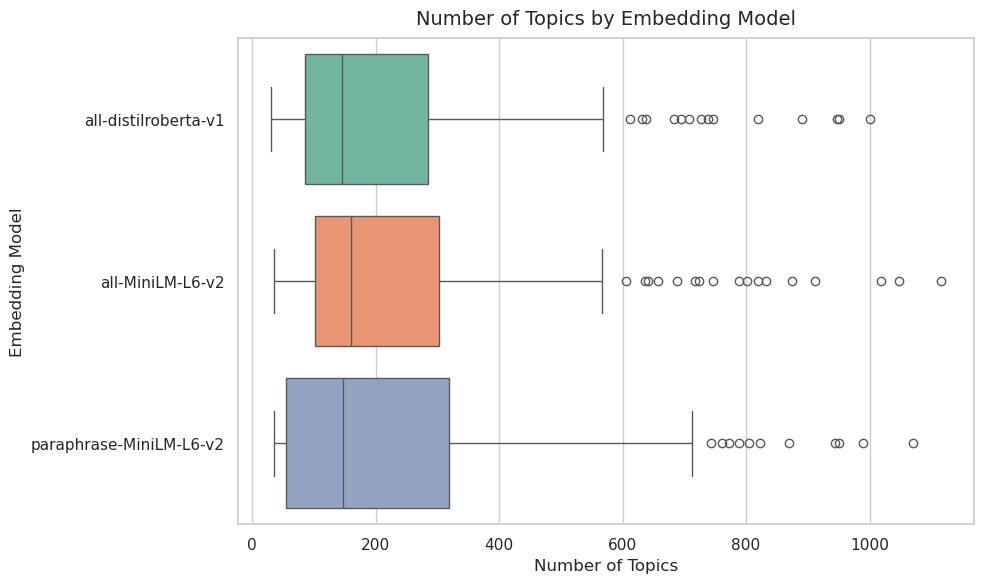

In [12]:
print("=== Number of Topics Global ===")
display(df_all["n_topics"].describe().round(2))

print("\n=== Número de tópicos — por Embedding ===")
display(df_all.groupby("embedding_model")["n_topics"].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_all, y="embedding_model", x="n_topics", palette="Set2", ax=ax)
ax.set_title("Number of Topics by Embedding Model", fontsize=14, pad=10)
ax.set_xlabel("Number of Topics")
ax.set_ylabel("Embedding Model")
plt.tight_layout()
plt.savefig('../reports/figures/gs_ntopics.png', dpi=300, bbox_inches='tight')
plt.show()

#### Número de Outliers

/tmp/ipykernel_2098391/4081282138.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


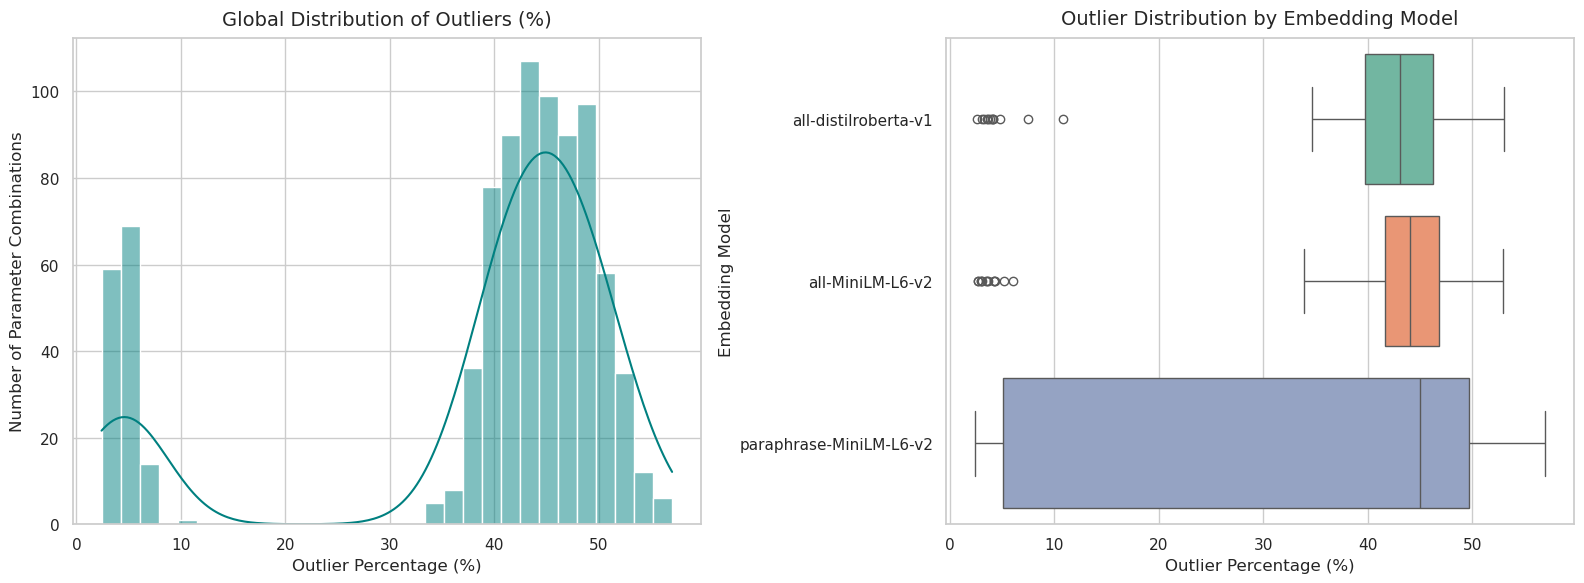

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribuição GLOBAL de Outliers (Histograma com KDE)
sns.histplot(
    data=df_all, 
    x="outliers_pct", 
    kde=True, 
    color="teal", 
    bins=30, 
    ax=axes[0]
)
axes[0].set_title("Global Distribution of Outliers (%)", fontsize=14, pad=10)
axes[0].set_xlabel("Outlier Percentage (%)")
axes[0].set_ylabel("Number of Parameter Combinations")

# 2. Distribuição LOCAL de Outliers por Modelo (Boxplot)
sns.boxplot(
    data=df_all, 
    y="embedding_model", 
    x="outliers_pct", 
    palette="Set2", 
    ax=axes[1]
)
axes[1].set_title("Outlier Distribution by Embedding Model", fontsize=14, pad=10)
axes[1].set_xlabel("Outlier Percentage (%)")
axes[1].set_ylabel("Embedding Model")

plt.tight_layout()
plt.savefig('../reports/figures/gs_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

#### Métricas

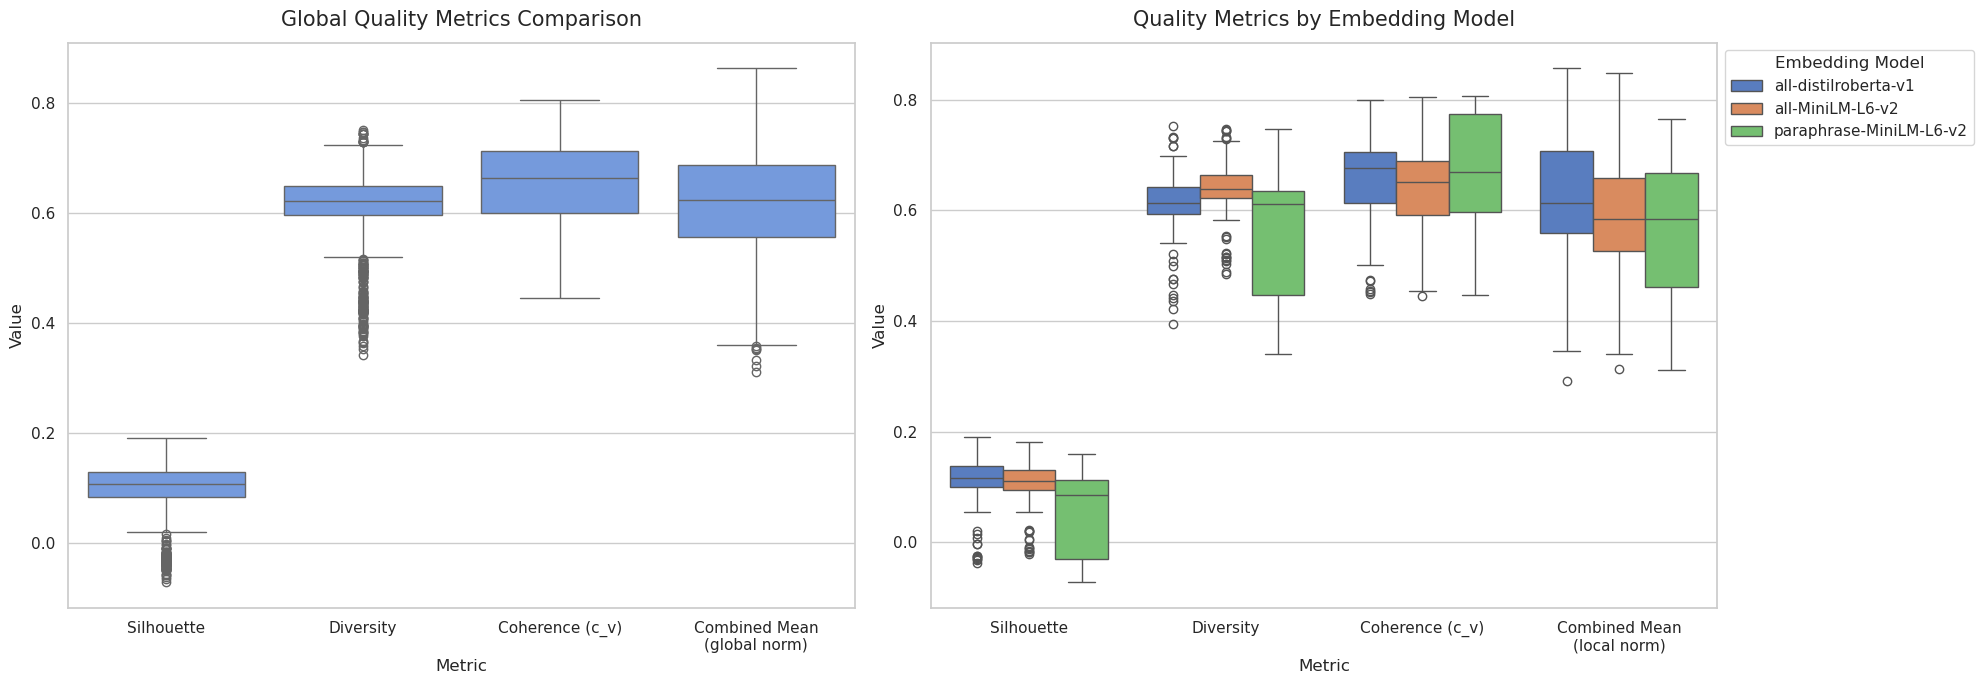

In [14]:
metricas_originais = ["silhouette", "diversity", "coherence_cv"]

# --- Painel 1: GLOBAL (métricas brutas + média normalizada GLOBAL) ---
metrics_df_global = df_all.melt(
    id_vars=["embedding_model"], 
    value_vars=metricas_originais + ["score_sdc_global"],
    var_name="Metric", 
    value_name="Value"
)
metrics_df_global["Metric"] = metrics_df_global["Metric"].replace({
    "silhouette": "Silhouette",
    "diversity": "Diversity",
    "coherence_cv": "Coherence (c_v)",
    "score_sdc_global": "Combined Mean\n(global norm)"
})

# --- Painel 2: POR EMBEDDING (métricas brutas + média normalizada LOCAL) ---
metrics_df_local = df_all.melt(
    id_vars=["embedding_model"], 
    value_vars=metricas_originais + ["score_sdc"],
    var_name="Metric", 
    value_name="Value"
)
metrics_df_local["Metric"] = metrics_df_local["Metric"].replace({
    "silhouette": "Silhouette",
    "diversity": "Diversity",
    "coherence_cv": "Coherence (c_v)",
    "score_sdc": "Combined Mean\n(local norm)"
})

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. GLOBAL (todos os embeddings juntos, score normalizado sobre o conjunto inteiro)
sns.boxplot(
    data=metrics_df_global, 
    x="Metric", 
    y="Value",
    color="cornflowerblue",
    ax=axes[0]
)
axes[0].set_title("Global Quality Metrics Comparison", fontsize=15, pad=12)
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Value")

# 2. POR EMBEDDING (score normalizado dentro de cada embedding)
sns.boxplot(
    data=metrics_df_local, 
    x="Metric", 
    y="Value", 
    hue="embedding_model", 
    palette="muted",
    ax=axes[1]
)
axes[1].set_title("Quality Metrics by Embedding Model", fontsize=15, pad=12)
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Value")
axes[1].legend(title="Embedding Model", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('../reports/figures/gs_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
colunas_exibir = ["embedding_model", "min_cluster_size", "min_samples", "n_neighbors", 
                   "n_components", "n_topics", "silhouette", "diversity", "coherence_cv", 
                   "outliers_pct", "score_sdc"]

# --- 3 candidatos: melhor score_sdc LOCAL (dentro de cada embedding) ---
print("=== Top 1 local por embedding (melhor score_sdc dentro do próprio modelo) ===")
melhores_locais = (
    df_all.dropna(subset=["score_sdc"])
    .sort_values("score_sdc", ascending=False)
    .groupby("embedding_model")
    .head(1)
)
display(melhores_locais[colunas_exibir])

=== Top 1 local por embedding (melhor score_sdc dentro do próprio modelo) ===


,embedding_model,min_cluster_size,min_samples,n_neighbors,n_components,n_topics,silhouette,diversity,coherence_cv,outliers_pct,score_sdc
263,all-distilroberta-v1,200,20,100,5,55,0.1834,0.6691,0.7402,38.2,0.856282
431,all-MiniLM-L6-v2,200,20,30,10,62,0.1718,0.6984,0.7249,38.3,0.848672
838,paraphrase-MiniLM-L6-v2,200,10,100,5,63,0.1072,0.6413,0.7287,42.3,0.765230


In [17]:
# --- 4 candidatos: melhor score_sdc_global (entre todos os embeddings) ---
print("\n=== Top 5 GLOBAL (melhor score_sdc_global considerando todos os embeddings juntos) ===")
colunas_exibir_global = colunas_exibir + ["score_sdc_global"]
melhores_globais = df_all.dropna(subset=["score_sdc_global"]).nlargest(5, "score_sdc_global")
display(melhores_globais[colunas_exibir_global])


=== Top 5 GLOBAL (melhor score_sdc_global considerando todos os embeddings juntos) ===


,embedding_model,min_cluster_size,min_samples,n_neighbors,n_components,n_topics,silhouette,diversity,coherence_cv,outliers_pct,score_sdc,score_sdc_global
263,all-distilroberta-v1,200,20,100,5,55,0.1834,0.6691,0.7402,38.2,0.856282,0.863344
262,all-distilroberta-v1,200,10,100,5,56,0.1834,0.6607,0.7432,39.9,0.851283,0.859293
431,all-MiniLM-L6-v2,200,20,30,10,62,0.1718,0.6984,0.7249,38.3,0.848672,0.858262
285,all-distilroberta-v1,200,5,100,10,61,0.1907,0.6738,0.7203,43.3,0.852491,0.858026
287,all-distilroberta-v1,200,20,100,10,57,0.1863,0.6737,0.7249,41.5,0.850314,0.856611
